In [6]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import math

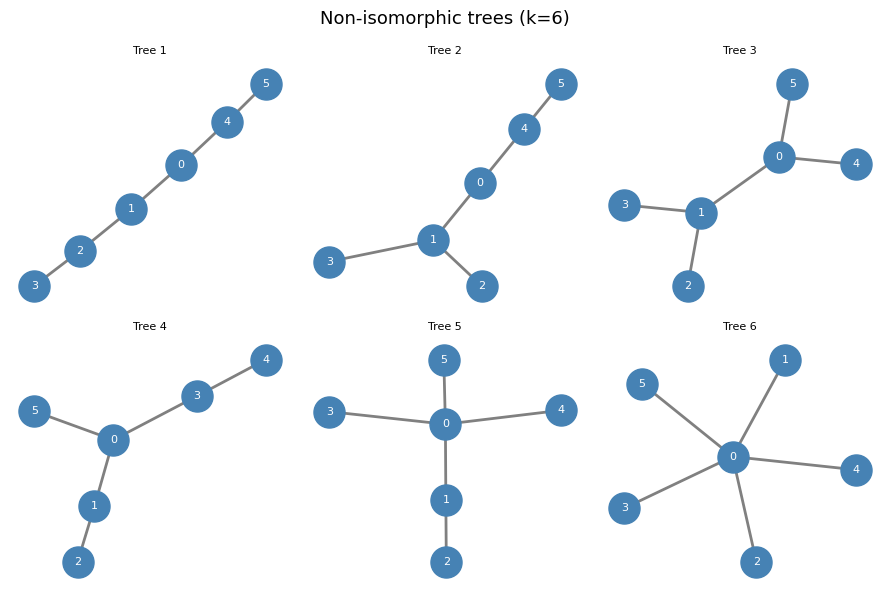

In [7]:



trees = list(nx.nonisomorphic_trees(6))
n_trees = len(trees)
cols = math.ceil(math.sqrt(n_trees))
rows = math.ceil(n_trees / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = axes.flatten()

for idx, (ax, G) in enumerate(zip(axes, trees)):
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, ax=ax, with_labels=True,
            node_color="steelblue", node_size=500,
            edge_color="gray", width=2,
            font_color="white", font_size=8)
    ax.set_title(f"Tree {idx+1}", fontsize=8)

for ax in axes[n_trees:]:
    ax.axis("off")

fig.suptitle("Non-isomorphic trees (k=6)", fontsize=13)
plt.tight_layout()
plt.show()

In [8]:
from GNN import GNN
from tree import Node, Tree
from homomorphism import total_hom, total_hom_preprocess, refine_colours
import pickle

In [9]:
def fb_test():
    with open("edges.pkl", "rb") as f:
        edges = pickle.load(f)
    
    G = GNN(edges=edges, directed=False)

    return G


[(342, 59), (238, 239), (17, 326), (80, 187), (325, 109), (224, 84), (161, 142), (122, 323), (161, 308), (142, 66), (308, 31), (136, 7), (271, 252), (255, 49), (48, 320), (3, 85), (246, 7), (109, 56), (109, 119), (239, 238)]


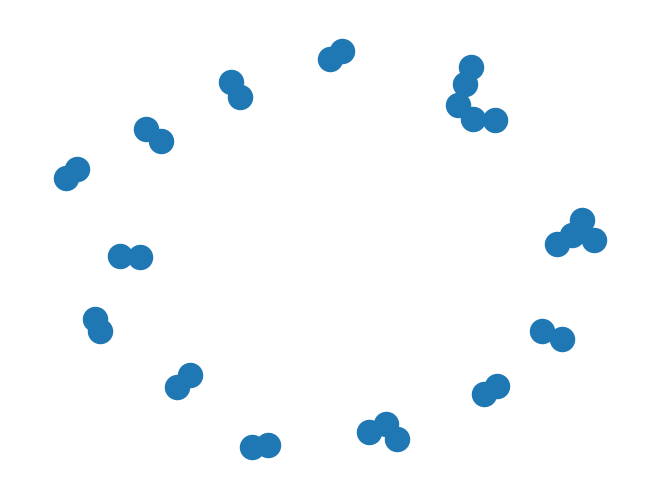

In [10]:
G = fb_test()
with open("edges.pkl", "rb") as f:
    edges = pickle.load(f)
print(edges[105:125])
nx.draw(nx.Graph(edges[105:125]))

In [11]:
T = Node("A")
T.children = [Node("B")]
T2 = Node("A")
T2.children = [Node("B"), Node("C")]
total_hom(T, G)

5038

In [12]:
reg_cases = [
        (5, 10), (5, 100), (5, 150), (5, 200), 
        (10, 20), (10, 100), (10, 150), (10, 200),
        (20, 30), (30, 40), (40, 50), (50, 100),
        (150, 200), (200, 250)
    ] # regular graph cases of degree d and number of nodes n (d, n)

bip_cases = [
    10, 20, 30, 40, 50, 100, 150, 200, 250, 300
]

def reg_test():
    arr = []
    for case in reg_cases:
        with open(f"../graphs/regular/reg_{case[0]}_{case[1]}.pkl", "rb") as f:
            edges = pickle.load(f)
        
        G = GNN(edges=edges, directed=False)

        arr.append(total_hom(T, G))

    return arr

def bip_test():
    arr = []
    for case in bip_cases:
        with open(f"../graphs/bipartite/bip_{case}.pkl", "rb") as f:
            edges = pickle.load(f)
        
        G = GNN(edges=edges, directed=False)

        print(f"Currently on case {case}")

        arr.append(total_hom(T, G))

    return arr


In [13]:
results = bip_test()
print(results)

Currently on case 10
Currently on case 20
Currently on case 30
Currently on case 40
Currently on case 50
Currently on case 100
Currently on case 150
Currently on case 200
Currently on case 250
Currently on case 300
[200, 800, 1800, 3200, 5000, 20000, 45000, 80000, 125000, 180000]


In [14]:
total_hom(T, G)

5038

In [15]:
def fb_test():
    with open("edges.pkl", "rb") as f:
        edges = pickle.load(f)
    
    G = GNN(edges=edges, directed=False)

    return G


In [16]:
G = GNN(edges=edges, directed=False)
A, colour_count = refine_colours(G)

In [17]:
trees = list(nx.generators.nonisomorphic_trees(9))

deltas = {i: [] for i in range(len(trees))}
A, colour_count = refine_colours(G)

tree = Tree(edges=list(trees[2].edges))

tree = tree.nodes[1]

total_hom_preprocess(tree, G, colour_count, A)

156352

In [18]:
import time
for i in range(10):
    print(f"Processing Iteration #{i + 1}...")
    for index, tree in enumerate(trees):
        delta = time.time()
        tree = Tree(edges=list(trees[i].edges))
        tree = tree.nodes[1]
        total_hom_preprocess(tree, G, colour_count, A)
        delta = time.time() - delta
        deltas[index].append(delta)
    print(f"Completed Iteration #{i + 1}!")

Processing Iteration #1...
Completed Iteration #1!
Processing Iteration #2...
Completed Iteration #2!
Processing Iteration #3...
Completed Iteration #3!
Processing Iteration #4...
Completed Iteration #4!
Processing Iteration #5...
Completed Iteration #5!
Processing Iteration #6...
Completed Iteration #6!
Processing Iteration #7...
Completed Iteration #7!
Processing Iteration #8...
Completed Iteration #8!
Processing Iteration #9...
Completed Iteration #9!
Processing Iteration #10...
Completed Iteration #10!


In [16]:
G = fb_test()

In [17]:
with open("edges.pkl", "rb") as f:
    edges = pickle.load(f)

In [18]:
edges

[(236, 186),
 (122, 285),
 (24, 346),
 (271, 304),
 (176, 9),
 (130, 329),
 (204, 213),
 (252, 332),
 (82, 65),
 (276, 26),
 (280, 272),
 (211, 199),
 (84, 236),
 (133, 62),
 (239, 172),
 (322, 53),
 (3, 170),
 (175, 46),
 (170, 176),
 (170, 56),
 (254, 194),
 (231, 117),
 (127, 135),
 (285, 103),
 (188, 133),
 (23, 116),
 (73, 299),
 (288, 315),
 (119, 323),
 (48, 57),
 (200, 98),
 (313, 63),
 (199, 304),
 (53, 346),
 (344, 239),
 (56, 67),
 (118, 325),
 (188, 119),
 (26, 277),
 (134, 56),
 (270, 76),
 (135, 36),
 (223, 170),
 (170, 274),
 (88, 21),
 (339, 119),
 (108, 197),
 (169, 271),
 (62, 236),
 (275, 273),
 (88, 186),
 (213, 186),
 (83, 23),
 (28, 312),
 (242, 57),
 (214, 20),
 (307, 71),
 (20, 333),
 (207, 322),
 (339, 168),
 (308, 277),
 (186, 341),
 (322, 122),
 (128, 9),
 (334, 252),
 (238, 265),
 (67, 141),
 (78, 273),
 (345, 122),
 (315, 345),
 (317, 158),
 (98, 21),
 (339, 38),
 (24, 302),
 (27, 54),
 (197, 139),
 (109, 118),
 (252, 291),
 (170, 142),
 (82, 271),
 (203, 3